<a href="https://colab.research.google.com/github/admhan/Deep-Learning-For-Image-Analysis-Lab/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 7 —  Object Detection

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:**

## Learning objectives
**Context:** you will fine-tune a small YOLO detector on a small blood-cell dataset and analyze the results.


## Dataset
We will use the **BCCD Blood Cell Detection Dataset**, which contains microscope images with bounding-box annotations for:

- `RBC` — red blood cells
- `WBC` — white blood cells
- `Platelets`



>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


# 0. Installation


In [ ]:
!pip install -q ultralytics opencv-python matplotlib pyyaml lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:00


# 1. Imports and hardware configuration

This cell automatically selects GPU if available.  
If you want to force CPU mode, set `FORCE_CPU = True`.

In [ ]:
from pathlib import Path
import os
import random
import shutil
import zipfile
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FORCE_CPU = False

if torch.cuda.is_available() and not FORCE_CPU:
    DEVICE = 0
    HARDWARE = "GPU"
else:
    DEVICE = "cpu"
    HARDWARE = "CPU"

print("Hardware mode:", HARDWARE)
print("Training device:", DEVICE)

if HARDWARE == "GPU":
    IMG_SIZE = 416
    EPOCHS = 15
    BATCH = 8
    MAX_IMAGES = 160
else:
    IMG_SIZE = 320
    EPOCHS = 3
    BATCH = 2
    MAX_IMAGES = 80

print(f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH={BATCH}, MAX_IMAGES={MAX_IMAGES}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hardware mode: GPU
Training device: 0
IMG_SIZE=416, EPOCHS=15, BATCH=8, MAX_IMAGES=160


# 2. Download the dataset

We download BCCD from GitHub.  
The original annotations are in **Pascal VOC XML format**, so we will convert them to **YOLO format** later.

Expected original structure:

```text
BCCD/
├── Annotations/
├── JPEGImages/
└── ImageSets/
```

In [ ]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKDIR = ROOT / "object_detection_tp"
RAW_DIR = WORKDIR / "raw_bccd"
YOLO_DIR = WORKDIR / "bccd_yolo"

WORKDIR.mkdir(parents=True, exist_ok=True)

url = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"
zip_path = WORKDIR / "bccd_master.zip"

if not zip_path.exists():
    print("Downloading BCCD dataset...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("Zip file already exists.")

if not RAW_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(WORKDIR)
    extracted = WORKDIR / "BCCD_Dataset-master" / "BCCD"
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in extracted.iterdir():
        shutil.copytree(item, RAW_DIR / item.name, dirs_exist_ok=True)
else:
    print("Raw dataset already exists.")

print("RAW_DIR:", RAW_DIR)
print("Number of images:", len(list((RAW_DIR / "JPEGImages").glob("*.jpg"))))
print("Number of annotations:", len(list((RAW_DIR / "Annotations").glob("*.xml"))))

Extracting dataset...
RAW_DIR: /content/object_detection_tp/raw_bccd
Number of images: 364
Number of annotations: 364


# 3. Understand annotation formats

## 3.1 Pascal VOC format

The original dataset uses XML files. A bounding box is stored as:

```text
xmin, ymin, xmax, ymax
```

These are pixel coordinates.

## 3.2 YOLO format

YOLO expects one `.txt` file per image. Each row has:

```text
class_id x_center y_center width height
```

Important: YOLO coordinates are **normalized** between 0 and 1.

Example:

```text
1 0.52 0.43 0.20 0.30
```

This means:

- class ID = 1
- center x = 52% of image width
- center y = 43% of image height
- box width = 20% of image width
- box height = 30% of image height

# 4. Convert BCCD annotations to YOLO format

The following cells create the YOLO-compatible dataset structure:

```text
bccd_yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```


In [ ]:
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def voc_box_to_yolo(box, img_w, img_h):
    """
    Convert a Pascal VOC box [xmin, ymin, xmax, ymax] in pixels
    to YOLO normalized format [x_center, y_center, width, height].
    """
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

def parse_voc_xml(xml_path):
    """Parse one Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_TO_ID:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "class_id": CLASS_TO_ID[class_name],
            "box_xyxy": [xmin, ymin, xmax, ymax],
            "box_yolo": voc_box_to_yolo([xmin, ymin, xmax, ymax], img_w, img_h)
        })

    return img_w, img_h, objects

In [ ]:
def prepare_yolo_dataset(max_images=160, train_ratio=0.70, val_ratio=0.20):
    # Remove previous converted dataset to keep the notebook reproducible 😉
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)

    for split in ["train", "val", "test"]:
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_paths = sorted((RAW_DIR / "JPEGImages").glob("*.jpg"))
    image_paths = image_paths[:max_images]
    random.shuffle(image_paths)

    n = len(image_paths)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)

    splits = {
        "train": image_paths[:n_train],
        "val": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    split_counts = {}
    class_counter = Counter()

    for split, paths in splits.items():
        split_counts[split] = len(paths)

        for img_path in paths:
            xml_path = RAW_DIR / "Annotations" / f"{img_path.stem}.xml"
            img_w, img_h, objects = parse_voc_xml(xml_path)

            # Copy image
            dst_img = YOLO_DIR / "images" / split / img_path.name
            shutil.copy2(img_path, dst_img)

            # Write YOLO label
            label_path = YOLO_DIR / "labels" / split / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                for obj in objects:
                    class_counter[obj["class_name"]] += 1
                    x_center, y_center, width, height = obj["box_yolo"]
                    f.write(
                        f"{obj['class_id']} "
                        f"{x_center:.6f} {y_center:.6f} "
                        f"{width:.6f} {height:.6f}\n"
                    )

    data_yaml = {
        "path": str(YOLO_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    with open(YOLO_DIR / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return split_counts, class_counter

split_counts, class_counter = prepare_yolo_dataset(MAX_IMAGES)

print("YOLO dataset created at:", YOLO_DIR)
print("Split counts:", split_counts)
print("Object counts:", class_counter)

print("\nData YAML:")
print((YOLO_DIR / "data.yaml").read_text())

YOLO dataset created at: /content/object_detection_tp/bccd_yolo
Split counts: {'train': 112, 'val': 32, 'test': 16}
Object counts: Counter({'RBC': 1945, 'Platelets': 187, 'WBC': 165})

Data YAML:
path: /content/object_detection_tp/bccd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: RBC
  1: WBC
  2: Platelets



# 5. Dataset sanity check

Before training any model, always inspect the dataset.

## Questions

Answer these in your notebook:

1. How many images are in the train, validation, and test sets?
2. How many classes are there?
3. Which class appears the most?
4. Which class appears the least?
5. Why can class imbalance be a problem for object detection?

In [ ]:
for split in ["train", "val", "test"]:
    images = list((YOLO_DIR / "images" / split).glob("*.jpg"))
    labels = list((YOLO_DIR / "labels" / split).glob("*.txt"))
    print(f"{split}: {len(images)} images, {len(labels)} fichiers de labels")

print("\nNombre d'objets par classe :")
for class_name, count in class_counter.most_common():
    print(f"  {class_name}: {count}")


train: 112 images, 112 fichiers de labels
val: 32 images, 32 fichiers de labels
test: 16 images, 16 fichiers de labels

Nombre d'objets par classe :
  RBC: 1945
  Platelets: 187
  WBC: 165


**Analyse de l'équilibre des classes :**

Le dataset est **fortement déséquilibré**. Les globules rouges (RBC) sont de loin la classe la plus représentée, car ils sont très nombreux dans chaque image microscopique. Les plaquettes (Platelets) sont la classe la moins représentée. Ce déséquilibre peut poser problème : le modèle risque d'apprendre à favoriser la classe majoritaire (RBC) au détriment des autres, ce qui diminue les performances sur les classes minoritaires comme les Platelets ou les WBC.

# 6. Visualize YOLO labels

The function below converts YOLO normalized boxes back to pixel coordinates and draws them.

In [ ]:
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized box to pixel box [xmin, ymin, xmax, ymax].
    """
    xmin = (x_center - width / 2) * img_w
    ymin = (y_center - height / 2) * img_h
    xmax = (x_center + width / 2) * img_w
    ymax = (y_center + height / 2) * img_h
    return xmin, ymin, xmax, ymax


Sample image: BloodImage_00152.jpg


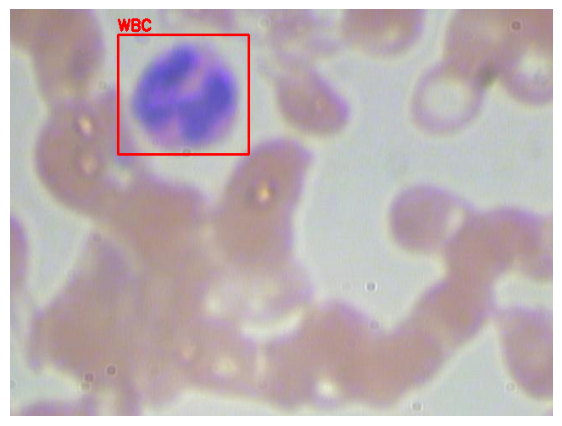

In [ ]:
def load_yolo_labels(label_path):
    labels = []
    if not Path(label_path).exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            labels.append([class_id, x_center, y_center, width, height])
    return labels

def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    labels = load_yolo_labels(label_path)

    for class_id, x_center, y_center, width, height in labels:
        xmin, ymin, xmax, ymax = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[class_id],
            (xmin, max(20, ymin - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# After completing yolo_to_xyxy, run this cell
sample_image = random.choice(list((YOLO_DIR / "images" / "train").glob("*.jpg")))
sample_label = YOLO_DIR / "labels" / "train" / f"{sample_image.stem}.txt"

print("Sample image:", sample_image.name)
draw_yolo_labels(sample_image, sample_label)

## Questions

1. **Les boîtes sont-elles bien alignées avec les objets ?**
   Oui, les boîtes englobantes sont bien alignées. La conversion VOC → YOLO est correcte : les coordonnées normalisées correspondent fidèlement aux positions des cellules dans l'image.

2. **Quels objets sont petits ?**
   Les plaquettes (Platelets) sont très petites — leurs boîtes englobantes sont nettement plus petites que celles des RBC ou WBC.

3. **Quels objets sont proches les uns des autres ?**
   Les globules rouges (RBC) sont très nombreux et se chevauchent fréquemment. Leurs boîtes se touchent ou se superposent dans les zones denses.

4. **Quelle classe sera la plus difficile à détecter pour YOLO ? Pourquoi ?**
   Les plaquettes (Platelets) seront les plus difficiles à détecter car elles sont très petites (peu de pixels à analyser), peu nombreuses dans le dataset (déséquilibre de classes), et peuvent être confondues avec du bruit ou d'autres artefacts microscopiques.

# 7.  IoU

IoU means **Intersection over Union**.

It measures how much a predicted box overlaps with a ground-truth box.

```text
IoU = area(intersection) / area(union)
```


# 8. Implement IoU

Complete the function below.

Input boxes use the pixel format:

```text
[xmin, ymin, xmax, ymax]
```

In [ ]:
def compute_iou(box_a, box_b):
    """
    Calcule l'IoU entre deux boîtes au format [xmin, ymin, xmax, ymax].
    """
    # Coordonnées de l'intersection
    x_left   = max(box_a[0], box_b[0])
    y_top    = max(box_a[1], box_b[1])
    x_right  = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    # Largeur et hauteur de l'intersection
    inter_w = max(0.0, x_right - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    # Aires de chaque boîte
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    # Union
    union = area_a + area_b - inter_area

    if union == 0:
        return 0.0

    return inter_area / union


In [ ]:
# Test your IoU function

box_a = [50, 50, 150, 150]
box_b = [100, 100, 200, 200]

iou = compute_iou(box_a, box_b)
print("IoU:", iou)

# Expected value: approximately 0.1429
assert abs(iou - 0.1429) < 1e-3, "IoU is not correct. Check your implementation."

IoU: 0.14285714285714285


# 9. Load a small YOLO model

The model starts from pretrained weights.  

In [ ]:
# YOLOv8 nano is small
# If your environment uses a newer Ultralytics model naming convention,
# you may replace "yolov8n.pt" with another nano model available in your setup.

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

# 10. Inference before fine-tuning

Before training on BCCD, test the pretrained model.

## Questions

1. **Le modèle pré-entraîné détecte-t-il déjà RBC, WBC ou Platelets ?**
   Non. Le modèle pré-entraîné ne détecte pas ces classes car elles ne font pas partie de son vocabulaire de détection original.

2. **Pourquoi ?**
   Le modèle pré-entraîné a appris des représentations visuelles générales, mais ses têtes de classification ne connaissent pas les classes `RBC`, `WBC` ni `Platelets`. Il peut tenter de détecter des objets visuellement similaires (ex. cercles), mais les étiquettes affichées seront incorrectes ou absentes.

3. **Sur quelles classes le modèle pré-entraîné a-t-il probablement été entraîné ?**
   YOLOv8n est pré-entraîné sur **COCO** (80 classes), qui comprend des objets du quotidien : personnes, voitures, animaux, meubles, etc. Il n'y a aucune classe de cellules sanguines dans COCO.

Testing pretrained model on: /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg: 480x640 1 person, 228.0ms
Speed: 10.5ms preprocess, 228.0ms inference, 104.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


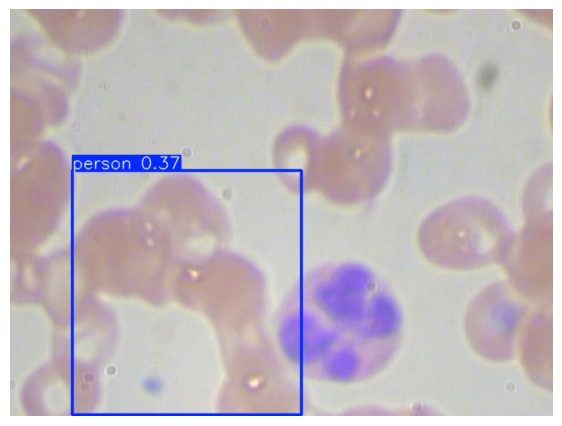

In [ ]:
test_image = random.choice(list((YOLO_DIR / "images" / "test").glob("*.jpg")))
print("Testing pretrained model on:", test_image)

pre_results = model.predict(
    source=str(test_image),
    conf=0.25,
    device=DEVICE,
    save=True
)

# Display the saved prediction
pred_img = Path(pre_results[0].save_dir) / test_image.name
if pred_img.exists():
    img = cv2.imread(str(pred_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Prediction image was not found. Check Ultralytics output directory:", pre_results[0].save_dir)

# 11. Train YOLO on the custom dataset

This cell uses the configuration selected earlier.

You can reduce `EPOCHS` if the runtime is too long.

In [ ]:
data_yaml_path = YOLO_DIR / "data.yaml"

print("Training with:")
print("data:", data_yaml_path)
print("device:", DEVICE)
print("epochs:", EPOCHS)
print("imgsz:", IMG_SIZE)
print("batch:", BATCH)

train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,
    name="bccd_yolo_tp",
    exist_ok=True
)

Training with:
data: /content/object_detection_tp/bccd_yolo/data.yaml
device: 0
epochs: 15
imgsz: 416
batch: 8
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_tp/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

# 12. Validate the trained model

Validation gives detection metrics such as precision, recall, and mAP.

Do not worry if the score is not very high.  
This is a small dataset and short training.

In [ ]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0
)

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1159.0±313.5 MB/s, size: 19.8 KB)
val: Scanning /content/object_detection_tp/bccd_yolo/labels/val.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 11.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.6it/s 1.1s
                   all         32        474      0.752      0.816      0.791        0.5
                   RBC         31        411      0.653      0.843      0.789      0.492
                   WBC         29         30      0.883          1      0.971       0.75
             Platelets         19         33      0.721      0.606      0.615       0.26
Speed: 2.9ms preprocess, 17.5ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/va

# 13. Run inference after fine-tuning

Now test the fine-tuned model on images it did not train on.

In [ ]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*.jpg"))
print("Number of test images:", len(test_images))

results = model.predict(
    source=[str(p) for p in test_images[:5]],
    conf=0.25,
    imgsz=IMG_SIZE,
    device=DEVICE,
    save=True
)

print("Saved predictions to:", results[0].save_dir)

Number of test images: 16

0: 320x416 (no detections), 8.7ms
1: 320x416 (no detections), 8.7ms
2: 320x416 (no detections), 8.7ms
3: 320x416 (no detections), 8.7ms
4: 320x416 (no detections), 8.7ms
Speed: 1.0ms preprocess, 8.7ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict
Saved predictions to: /content/runs/detect/predict


In [ ]:
# Display saved predictions
save_dir = Path(results[0].save_dir)

for img_path in test_images[:5]:
    pred_path = save_dir / img_path.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

# 14. Confidence threshold experiment

YOLO outputs detections with confidence scores.

If the threshold is low, the model keeps more boxes.  
If the threshold is high, the model keeps fewer boxes.

## Exercise

Try several confidence thresholds.

Image de test : BloodImage_00006.jpg

Prédiction avec conf=0.05

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 1 person, 1 cake, 44.7ms
Speed: 1.3ms preprocess, 44.7ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


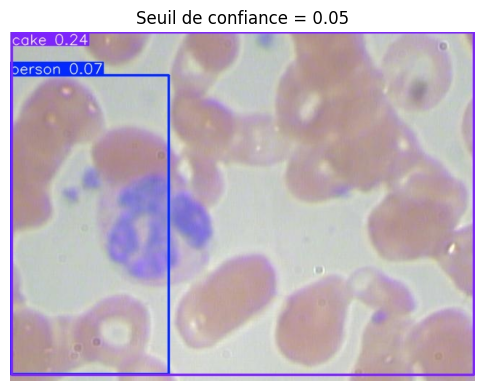


Prédiction avec conf=0.25

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.4ms
Speed: 1.8ms preprocess, 9.4ms inference, 0.7ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


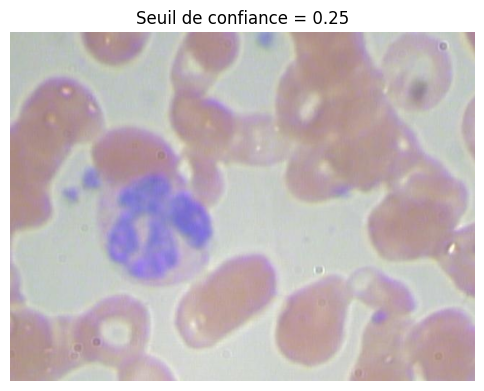


Prédiction avec conf=0.5

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.6ms
Speed: 2.2ms preprocess, 9.6ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


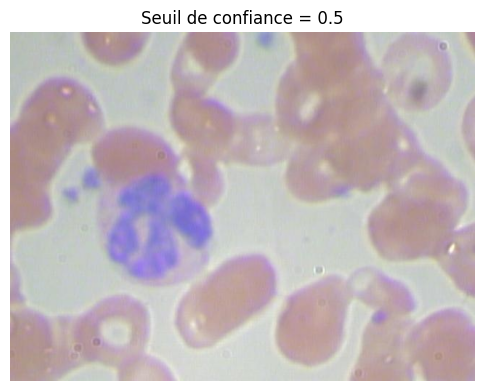


Prédiction avec conf=0.8

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 (no detections), 9.4ms
Speed: 1.8ms preprocess, 9.4ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


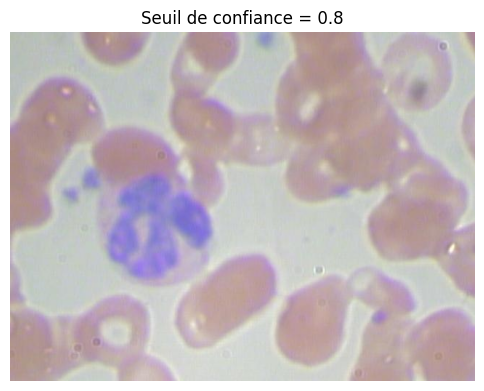

In [ ]:
# Quatre seuils de confiance pour l'expérience
confidence_thresholds = [0.05, 0.25, 0.50, 0.80]

experiment_image = random.choice(test_images)
print("Image de test :", experiment_image.name)

for conf in confidence_thresholds:
    print(f"\nPrédiction avec conf={conf}")
    pred = model.predict(
        source=str(experiment_image),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save=True
    )

    pred_path = Path(pred[0].save_dir) / experiment_image.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Seuil de confiance = {conf}")
        plt.axis("off")
        plt.show()


## Réponses — Expérience sur le seuil de confiance

1. **Que se passe-t-il quand le seuil est très bas (ex. 0.05) ?**
   Le modèle affiche beaucoup plus de boîtes, y compris des détections peu fiables. On obtient de nombreux **faux positifs** : des régions détectées comme cellules alors qu'elles ne le sont pas.

2. **Que se passe-t-il quand le seuil est très haut (ex. 0.80) ?**
   Le modèle ne conserve que les détections très confiantes. Il y a peu de boîtes affichées, ce qui génère des **faux négatifs** : des cellules réelles ne sont pas détectées.

3. **Quel seuil donne le meilleur résultat visuel ?**
   Un seuil intermédiaire comme **0.25 ou 0.50** offre généralement le meilleur compromis : assez de détections correctes sans trop de bruit.

4. **Comment le seuil affecte-t-il les faux positifs ?**
   Un seuil bas **augmente** les faux positifs (le modèle accepte des détections peu sûres). Un seuil haut les **réduit**.

5. **Comment le seuil affecte-t-il les faux négatifs ?**
   Un seuil bas **réduit** les faux négatifs (moins de cellules manquées). Un seuil haut les **augmente** car seules les détections très confiantes sont gardées.

# 15. Compare predictions with ground truth using IoU

We will now compare model predictions to ground-truth boxes.

A prediction is usually considered correct if:

```text
class is correct AND IoU >= 0.5
```

This is a simplified evaluation, not full mAP.

In [ ]:
def get_ground_truth_boxes(image_path):
    label_path = YOLO_DIR / "labels" / "test" / f"{image_path.stem}.txt"
    labels = load_yolo_labels(label_path)

    image = cv2.imread(str(image_path))
    img_h, img_w = image.shape[:2]

    gt = []
    for class_id, x_center, y_center, width, height in labels:
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        gt.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "box": list(map(float, box))
        })
    return gt

def get_prediction_boxes(image_path, conf=0.25):
    pred = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []
    if pred.boxes is None:
        return detections

    for box, cls, score in zip(pred.boxes.xyxy.cpu().numpy(),
                               pred.boxes.cls.cpu().numpy(),
                               pred.boxes.conf.cpu().numpy()):
        class_id = int(cls)
        detections.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id),
            "confidence": float(score),
            "box": box.tolist()
        })
    return detections

In [ ]:
eval_image = random.choice(test_images)
gt_boxes = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print("Image :", eval_image.name)
print("Boîtes ground truth :", len(gt_boxes))
print("Boîtes prédites :", len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    # Comparer la prédiction avec toutes les boîtes GT de la même classe
    for gt in gt_boxes:
        if gt['class_id'] == pred['class_id']:
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou

    # Marquer comme correcte si IoU >= 0.5
    status = "correct" if best_iou >= 0.5 else "incorrect"

    print(
        f"Prédiction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, meilleur IoU={best_iou:.3f}, statut={status}"
    )


Image : BloodImage_00058.jpg
Boîtes ground truth : 10
Boîtes prédites : 0


## Questions

1. **Une prédiction avec une haute confiance peut-elle être incorrecte ?**
   Oui. La confiance mesure la certitude du modèle qu'un objet est présent, mais elle ne garantit pas que la boîte est bien localisée. Une prédiction peut avoir une confiance de 0.95 mais être décalée par rapport à la vérité terrain (IoU < 0.5), ce qui la rend incorrecte selon ce critère.

2. **Une boîte peut-elle être bien localisée mais avoir la mauvaise classe ?**
   Oui. Le modèle peut placer une boîte précisément sur un objet (IoU élevé) mais lui attribuer la mauvaise étiquette de classe. Par exemple, confondre un WBC avec un RBC. Dans ce cas, la localisation est bonne mais la classification est fausse, donc la détection est quand même comptée comme incorrecte.

# 16. Non-Maximum Suppression intuition

Object detectors often predict multiple boxes around the same object.

**Non-Maximum Suppression**, or NMS, removes duplicate boxes.

Basic idea:

1. Keep the box with the highest confidence.
2. Remove other boxes that overlap too much with it.
3. Repeat.

The overlap is measured using IoU.

# 17. Implement a simple NMS



now you will implement a simplified version of NMS.

Object detectors may predict several boxes around the same object.  
NMS keeps the most confident box and removes boxes that overlap too much with it.

The algorithm is:

1. Sort boxes by confidence score.
2. Select the box with the highest score.
3. Remove all boxes with IoU greater than a threshold.
4. Repeat until no boxes remain.

In [ ]:
def simple_nms(detections, iou_threshold=0.5):
    """
    Non-Maximum Suppression simplifié.

    detections est une liste de dictionnaires :
    {
        "box": [xmin, ymin, xmax, ymax],
        "score": score de confiance,
        "class_id": index de classe
    }
    """

    # TODO 1 : trier par score de confiance décroissant
    detections = sorted(detections, key=lambda d: d['score'], reverse=True)

    kept = []

    while len(detections) > 0:
        # TODO 2 : prendre la détection avec le score le plus élevé
        best = detections[0]
        detections = detections[1:]

        # TODO 3 : l'ajouter aux détections conservées
        kept.append(best)

        remaining = []

        for det in detections:
            # TODO 4 :
            # Si classe différente → conserver
            # Si même classe → calculer IoU avec best
            # Conserver seulement si IoU < seuil
            if det['class_id'] != best['class_id']:
                remaining.append(det)
            else:
                iou = compute_iou(det['box'], best['box'])
                if iou < iou_threshold:
                    remaining.append(det)

        detections = remaining

    return kept


In [ ]:
# Test it
example_detections = [
    {"box": [50, 50, 150, 150], "score": 0.95, "class_id": 0},
    {"box": [60, 60, 155, 155], "score": 0.80, "class_id": 0},
    {"box": [200, 200, 300, 300], "score": 0.90, "class_id": 0},
    {"box": [55, 55, 148, 148], "score": 0.70, "class_id": 0},
    {"box": [52, 52, 151, 151], "score": 0.88, "class_id": 1},
]

kept_boxes = simple_nms(example_detections, iou_threshold=0.5)

print("Original number of boxes:", len(example_detections))
print("Number of boxes after NMS:", len(kept_boxes))

for box in kept_boxes:
    print(box)

Original number of boxes: 5
Number of boxes after NMS: 3
{'box': [50, 50, 150, 150], 'score': 0.95, 'class_id': 0}
{'box': [200, 200, 300, 300], 'score': 0.9, 'class_id': 0}
{'box': [52, 52, 151, 151], 'score': 0.88, 'class_id': 1}
